---
<a id='top'></a>
# Analysis

The documentation below describes how to use the code base to analyze output from the U-net model. 
This guide assumes you have read through the {doc}`Installation <installation>`, {doc}`Data <data>`, and {doc}`Running the model <run_model>` pages and have model output available for analysis on Animus.
<!-- Note: for linking between documents, use the `doc` role defined in the [Sphinx documentation](https://docs.readthedocs.com/platform/stable/guides/cross-referencing-with-sphinx.html#the-doc-role). 
TLDR: Create a link to a different document by typing `{doc}`, followed by the name of the file surrounded by backticks, excluding the extension. If you would like to change the rendered text of the link, surround the desired link text in backticks, then add the name of the file in angle brackets, in the format: "{doc}`Click here <filename>`".  -->

## Table of Contents

- [Before you start](#before_you_start)
- [Exploring a dataset](#exploring_a_dataset)
- [Plotting results](#plotting_results)

---
<a id='before_you_start'></a>
[back to top](#top)
## Before you start

A good thing to do before starting is to check the version of the `unox` package you are using and the current working directory. 
The first time you run a cell in a notebook in VSCodium, it will ask you to select an environment to use. 
Be sure to select `uplt`, or whatever you named the environment during {doc}`installation <installation>`.

In [1]:
import unox
print(unox.__version__)

0.1.1


In [2]:
import os
os.getcwd()

'/home/mschee/unox/docs'

The current working directory for this example guide is within the `docs/` directory.
For this reason, most of the file paths below are prepended by `../` to indicate that you must first go up one directory level, then search for the file. 

When doing analysis, I generally use a Jupyter Notebook.
The notebook named `plot_tests.ipynb` is deliberately left blank as a place to test things out.
I encourage you to follow along in that notebook as you go through this guide, noting any differences you need to keep track of based on the working directory and trying out different combinations that aren't explicitly explored here.

---
<a id='exploring_a_dataset'></a>
[back to top](#top)
## Exploring a dataset

A number of sample datasets are listed below. 
Pick one to explore with this section.

In [12]:
# ERA5 U-wind component for 2019
sample_dataset = '../datafiles/sample_data/2019u10.nc'
# `t106` NOx emissions over North America for 2019
sample_dataset = '../datafiles/sample_data/nox_2019_t106_US.nc'
# TROPESS reanalysis NOx for 2021
sample_dataset = '../datafiles/sample_data/TROPESS_reanalysis_mon_emi_nox_anth_2021.nc'
# An example input netCDF
sample_dataset = '../inputfiles/no2_input_test1/no2_input_test1.nc'
# An example output netCDF
sample_dataset = '../HPC_runs/write_docs1/predictions.nc'

The code base contains a number of methods of exploring a dataset that is in a netCDF file.
The simplest way to see what a dataset contains is to load it with `xarray`

In [13]:
from xarray import open_dataset 

open_dataset(sample_dataset)

<xarray.Dataset> Size: 39MB
Dimensions:      (time: 728, lat: 56, lon: 120)
Coordinates:
  * time         (time) object 6kB 2019-01-02 00:00:00 ... 2020-12-31 00:00:00
  * lat          (lat) float32 224B 11.78 12.9 14.02 15.14 ... 71.21 72.34 73.46
  * lon          (lon) float32 480B -174.4 -173.2 -172.1 ... -42.75 -41.62 -40.5
Data variables:
    nox_pred     (time, lat, lon) float32 20MB ...
    nox_pred_s2  (time, lat, lon) float32 20MB ...

/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


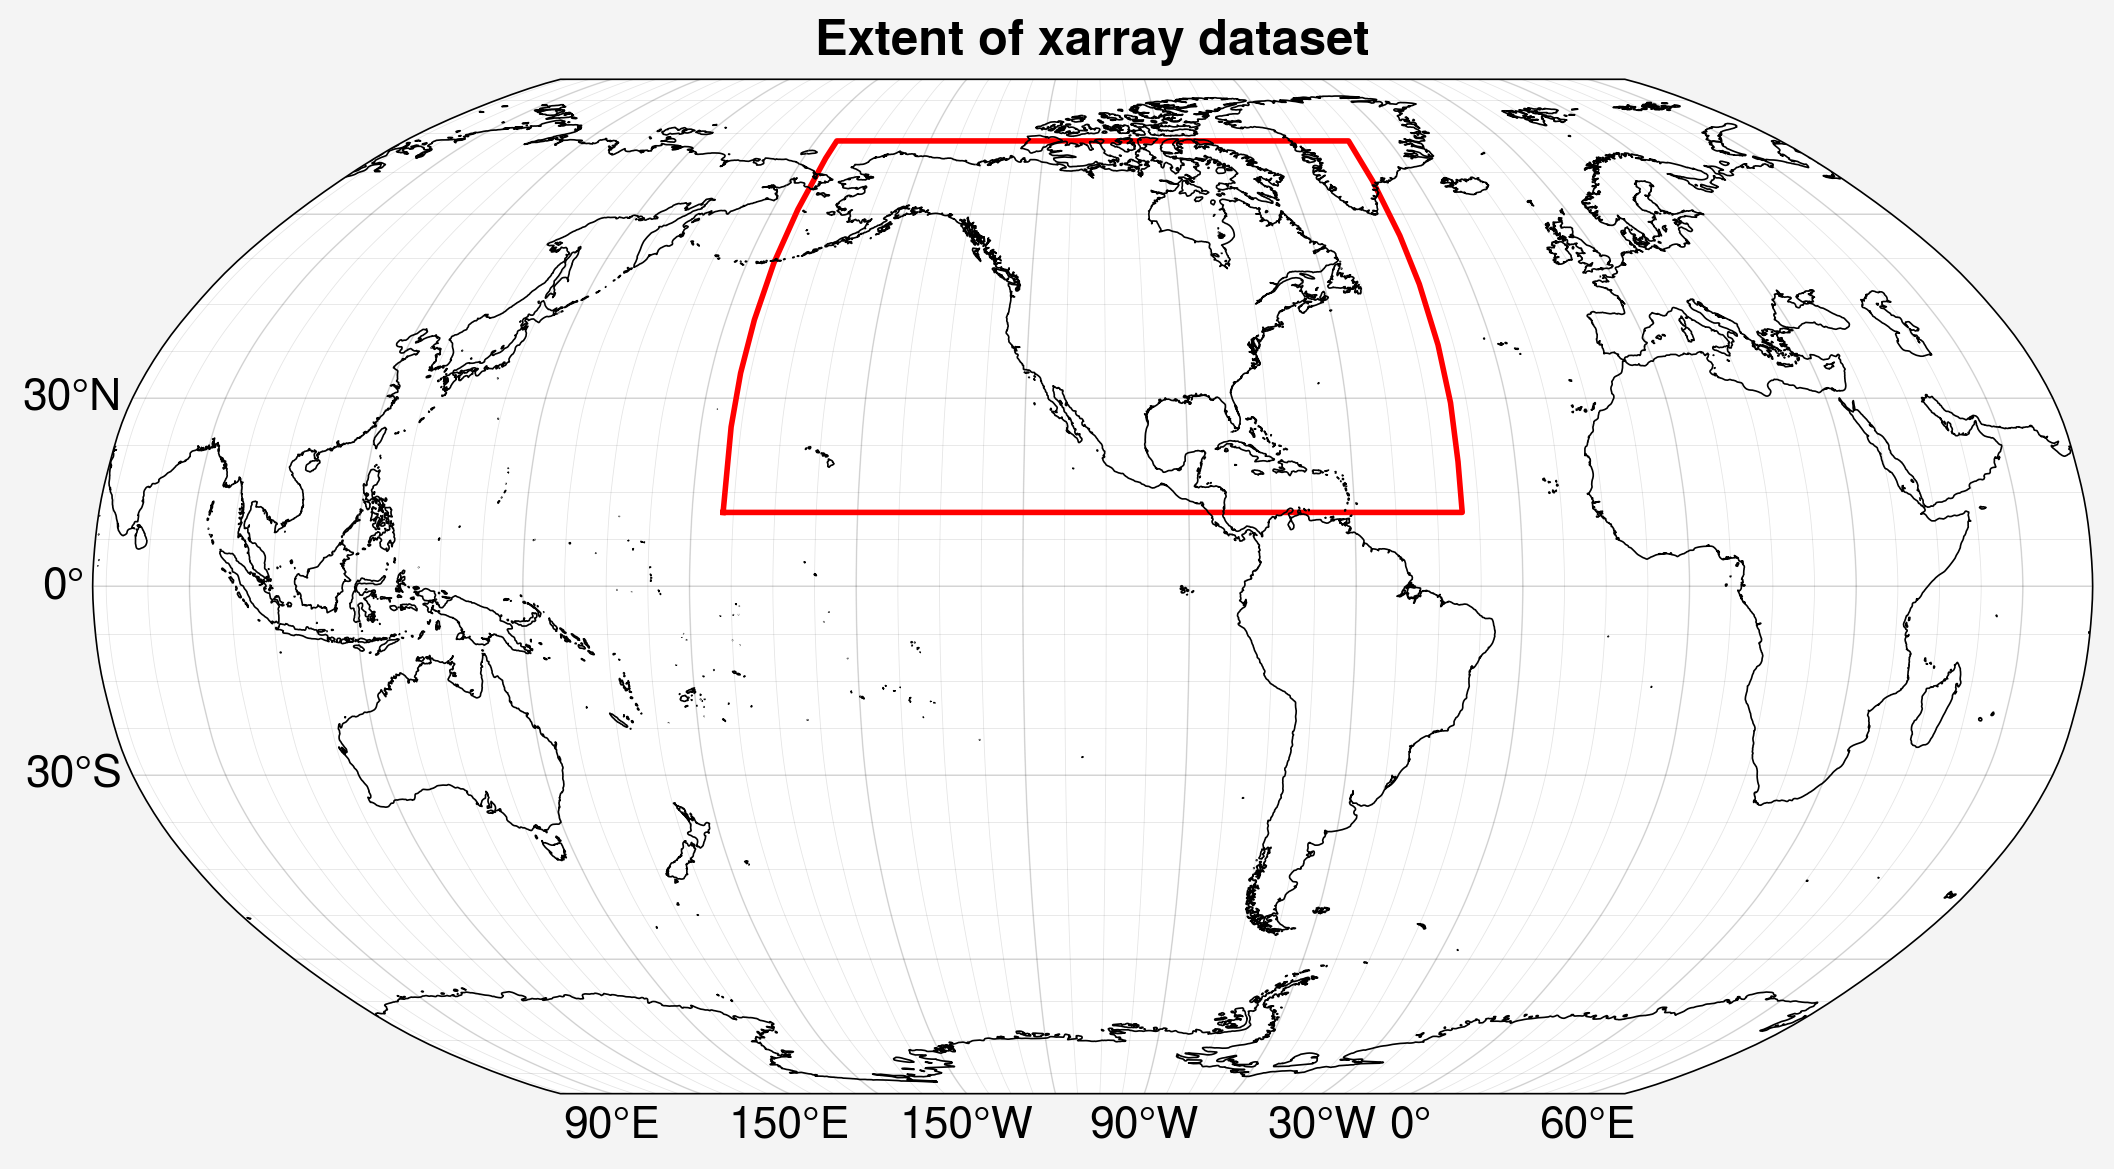

In [5]:
from unox.plotting import plot_extent 

extent_plot = plot_extent('../HPC_runs/write_docs1/predictions.nc')

---
<a id='plotting_results'></a>
[back to top](#top)
## Plotting results

/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/mschee/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `m

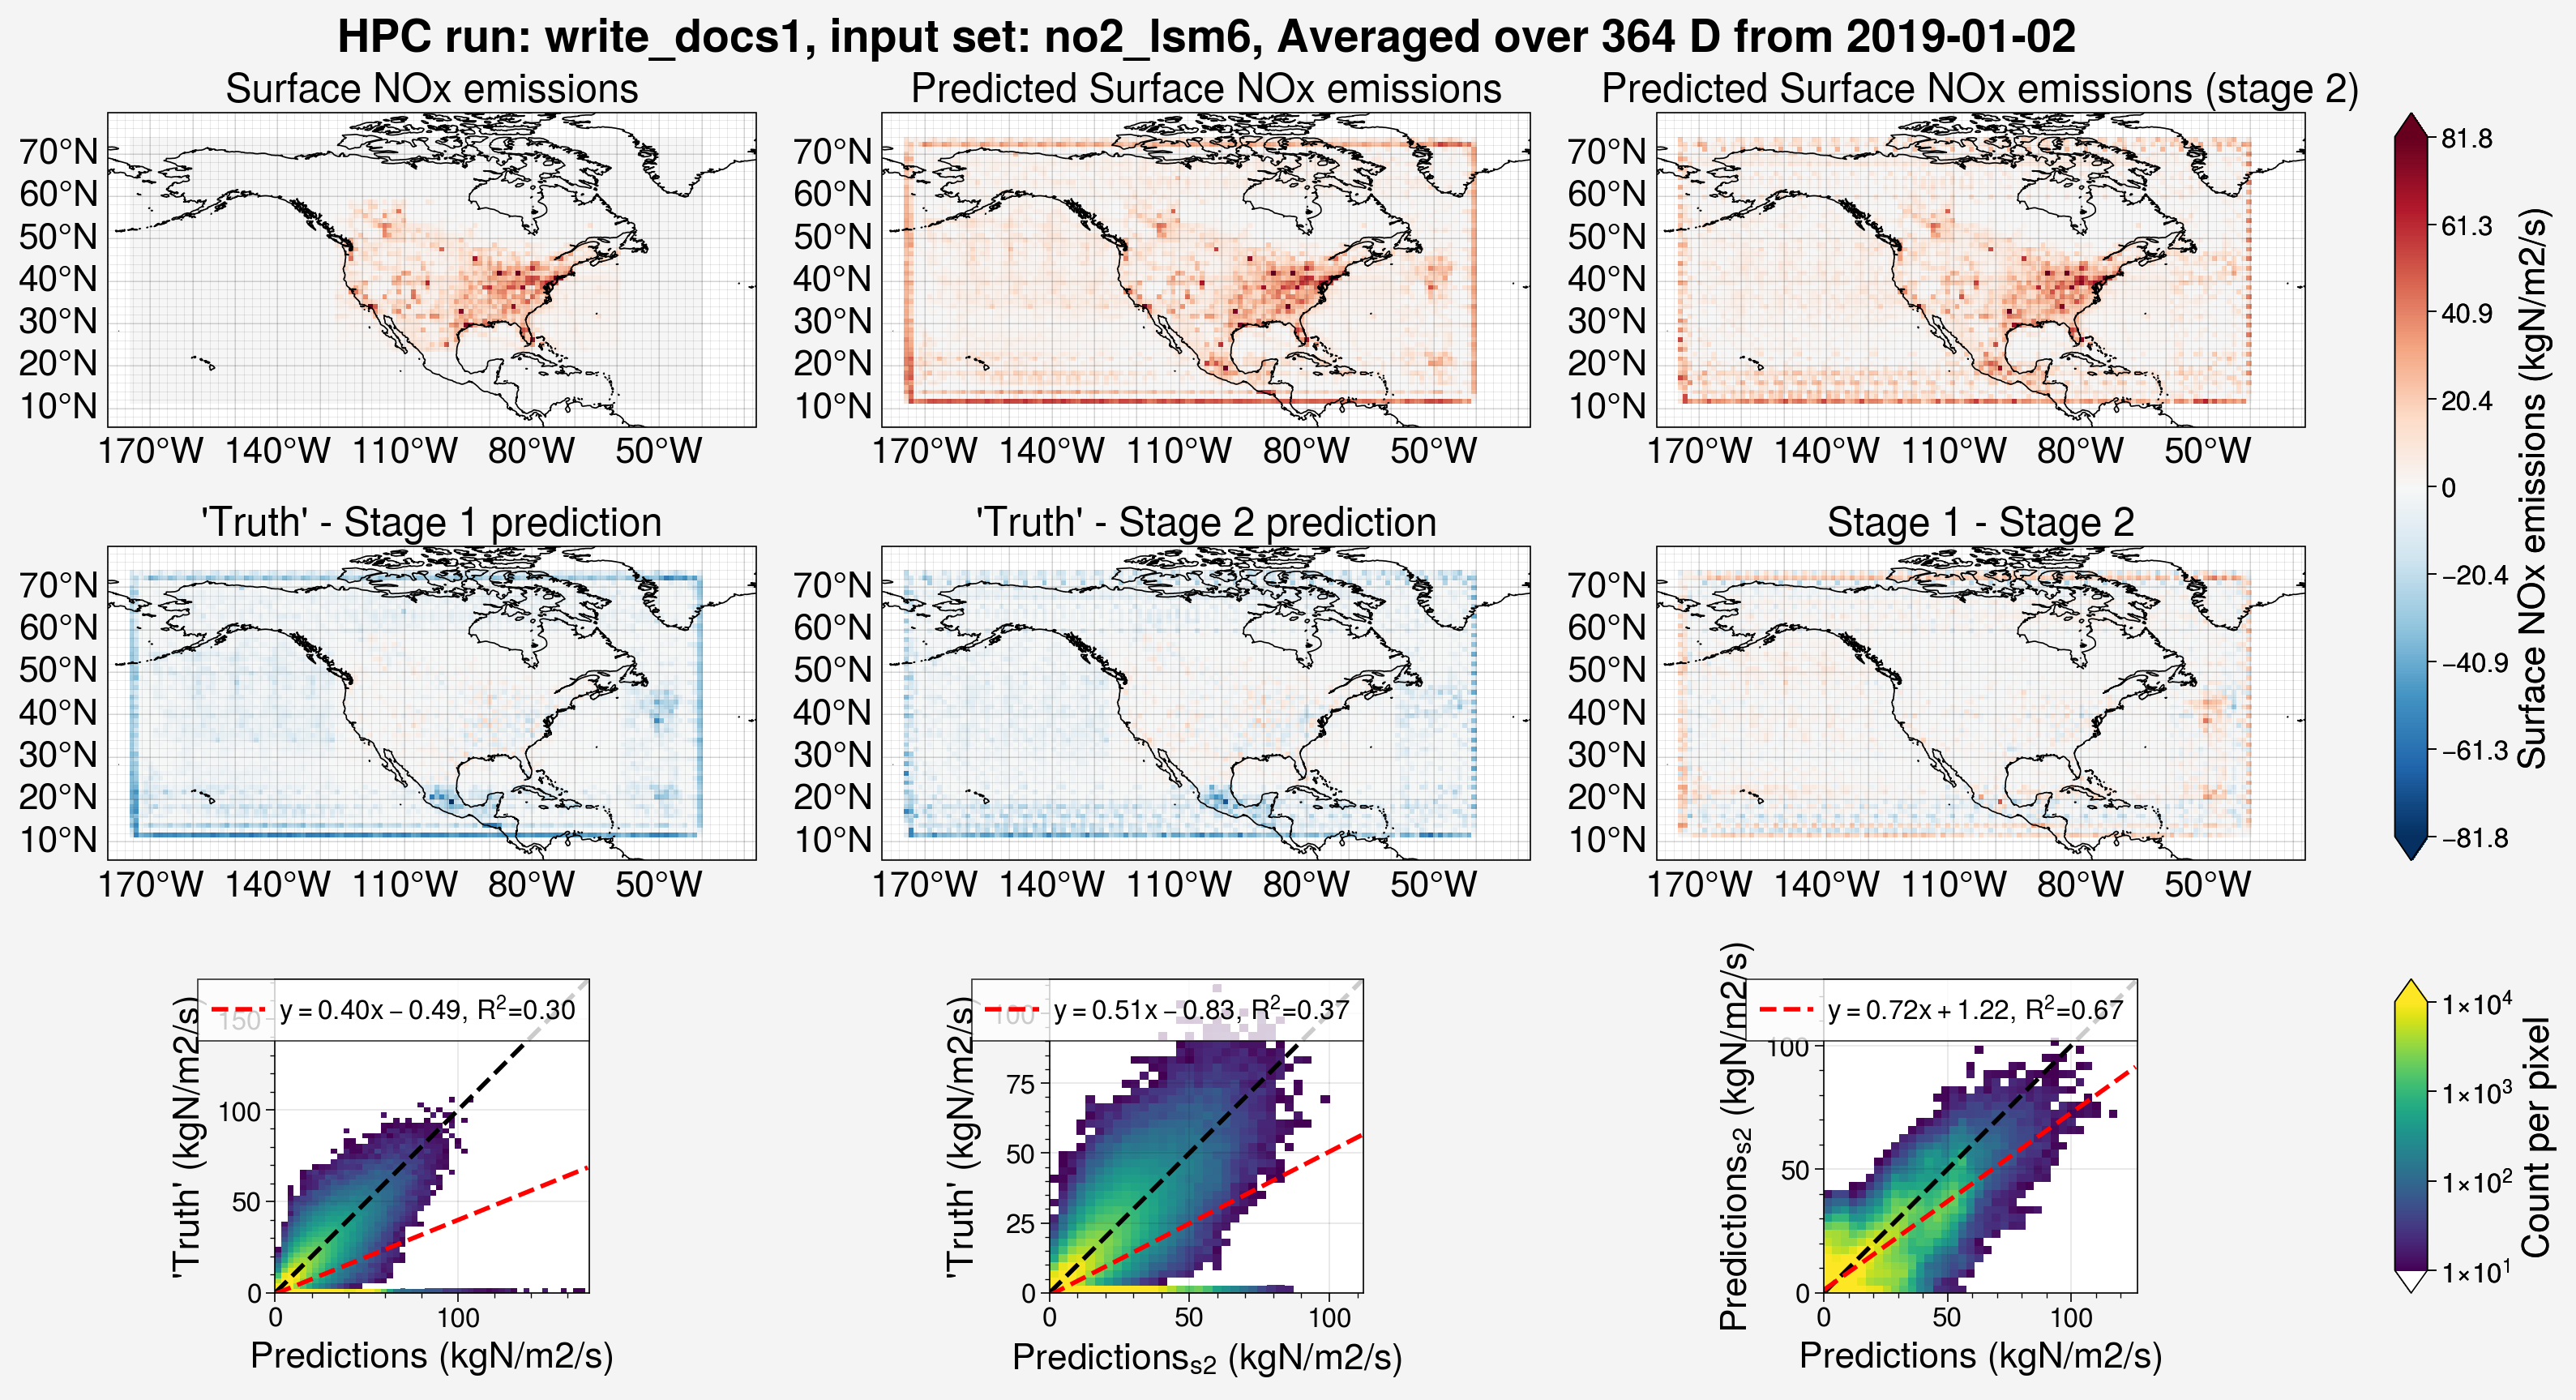

In [3]:
from unox.plotting import plot_comp_maps

this_plt = plot_comp_maps(
    HPC_run = 'write_docs1',
    year = 2019,
    datetime='2019-01-02T00:00:00',
    avg_over='364D',
    restrict_lat_lon_to=None,
    add_corr_plots=True,
)